In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from google.colab import drive
import pandas as pd
import joblib
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/datasets/diabetes.csv'

data = np.genfromtxt(file_path, delimiter=',', skip_header=1)
X = data[:, :-1]
y = data[:, -1]
print(f"Kích thước X: {X.shape}, Kích thước y: {y.shape}")


Kích thước X: (768, 8), Kích thước y: (768,)


Trực quan hóa dữ liệu sử dụng biểu đồ Histogram để thể hiện rõ sự phân bố của từng đặc trưng

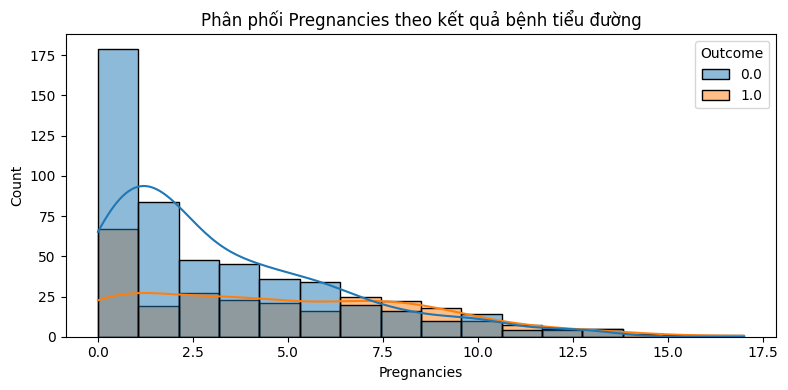

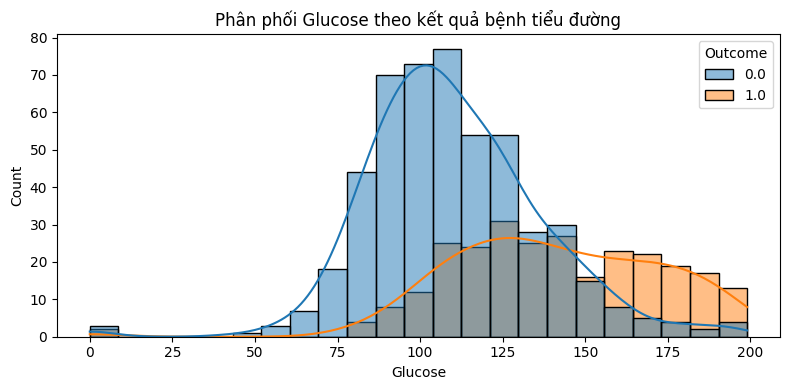

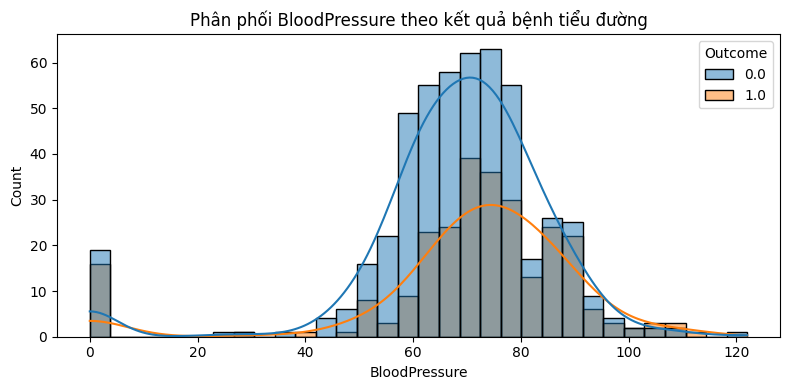

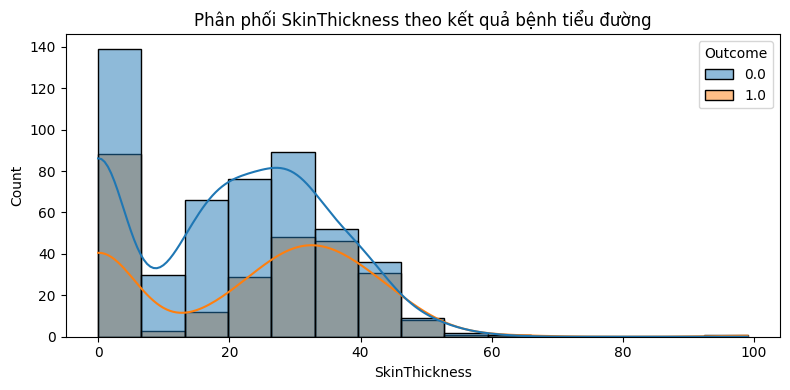

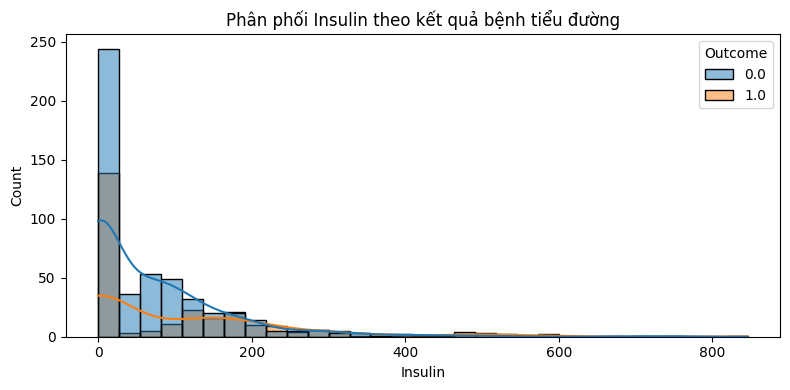

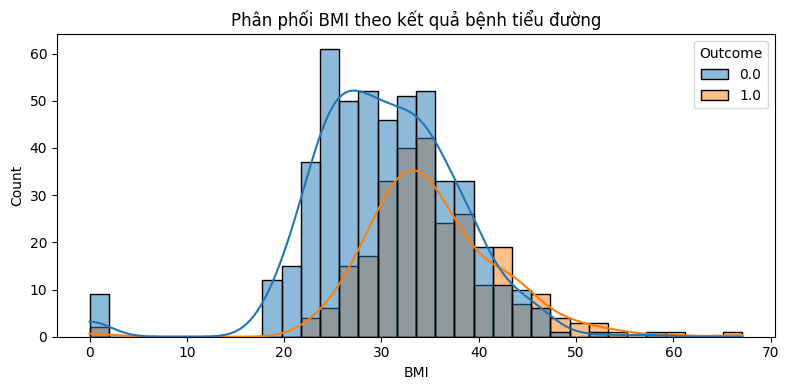

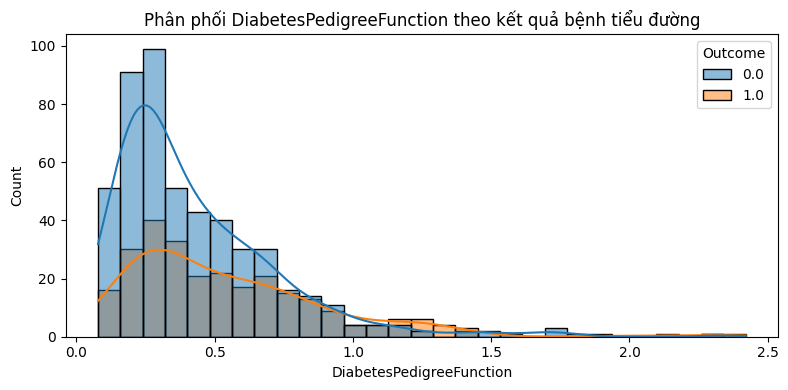

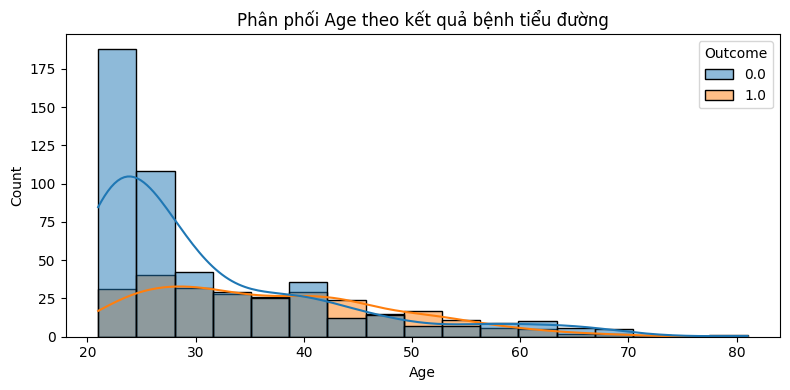

In [ ]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.DataFrame(data, columns=columns)

for col in df.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='Outcome', kde=True)
    plt.title(f'Phân phối {col} theo kết quả bệnh tiểu đường')
    plt.tight_layout()
    plt.show()

Chuẩn hóa dữ liệu cho các đặc trưng


In [ ]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

Chia dữ liệu thành tập huấn luyện và tập kiểm tra.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

Thêm cột bias vào X_train và X_test (bias = 1)

In [ ]:
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]


Xây dựng các hàm hỗ trợ


1.   Hàm sigmoid để tính xác suất.
2.   Hàm cost để tính toán độ mất mát.
3.   Hàm batch gradient descent để huấn luyện cho toàn bộ dữ liệu





In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [ ]:
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    cost = -(1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost


In [ ]:
def predict(X, theta):
    probabilities = sigmoid(np.dot(X, theta))
    return [1 if p >= 0.5 else 0 for p in probabilities]


In [ ]:
def batch_gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []
    acc_history = []

    for _ in range(iterations):
        h = sigmoid(np.dot(X, theta))
        gradient = (1/m) * np.dot(X.T, (h - y))
        theta -= learning_rate * gradient
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history


In [ ]:
theta = np.zeros(X_train.shape[1])
theta_bgd, cost_history_bgd = batch_gradient_descent(X_train, y_train, theta, learning_rate=0.01, iterations=1000)


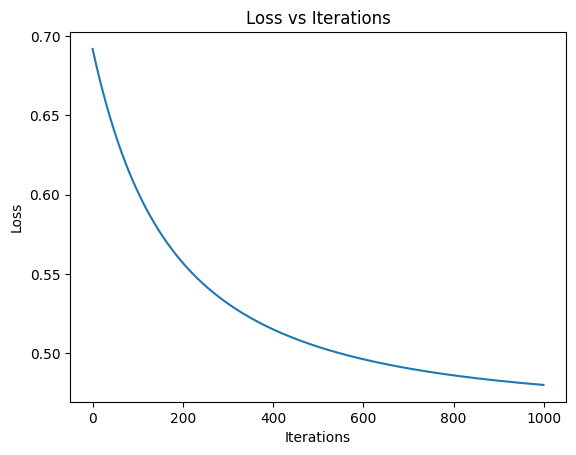

In [ ]:
plt.plot(cost_history_bgd)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()

In [ ]:
y_pred_bgd = predict(X_test, theta_bgd)

acc = accuracy_score(y_test, y_pred_bgd)
print(f"Accuracy (Batch GD): {acc}")

cr = classification_report(y_test, y_pred_bgd)
print(f"Classification Report (Batch GD):\n {cr}")


Accuracy (Batch GD): 0.7337662337662337
Classification Report (Batch GD):
               precision    recall  f1-score   support

         0.0       0.80      0.79      0.79        99
         1.0       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



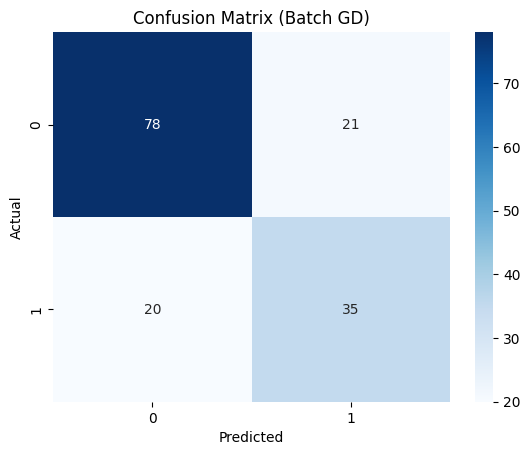

In [ ]:
cm = confusion_matrix(y_test, y_pred_bgd)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Batch GD)')
plt.show()


Hàm Mini batch gradient descent để chia dữ liệu ra thành từng đoạn để tính toán


In [ ]:
def mini_batch_gradient_descent(X, y, theta, learning_rate, iterations, batch_size):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        idx = np.random.permutation(m)
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            h = sigmoid(np.dot(X_batch, theta))
            gradient = (1/len(y_batch)) * np.dot(X_batch.T, (h - y_batch))
            theta -= learning_rate * gradient

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history



In [ ]:
theta = np.zeros(X_train.shape[1])
theta_mbgd, cost_history_mbgd = mini_batch_gradient_descent(X_train, y_train, theta, learning_rate=0.01, iterations=1000, batch_size=32)


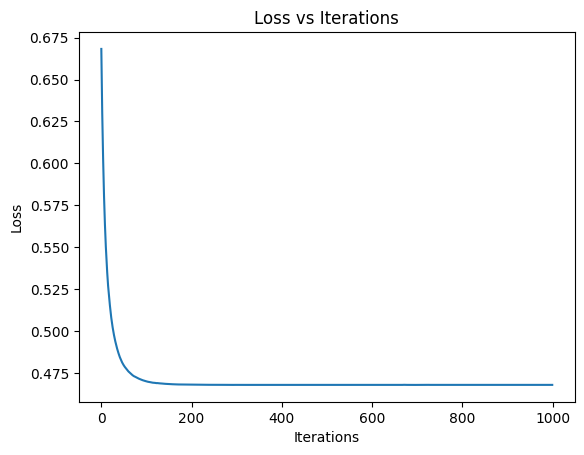

In [ ]:
plt.plot(cost_history_mbgd)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()


In [ ]:
y_pred_mbgd = predict(X_test, theta_mbgd)

acc = accuracy_score(y_test, y_pred_mbgd)
print(f"Accuracy (Mini-batch GD): {acc}")
cr = classification_report(y_test, y_pred_mbgd)
print(f"Classification Report (Mini-batch GD):\n {cr}")


Accuracy (Mini-batch GD): 0.7467532467532467
Classification Report (Mini-batch GD):
               precision    recall  f1-score   support

         0.0       0.81      0.80      0.80        99
         1.0       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



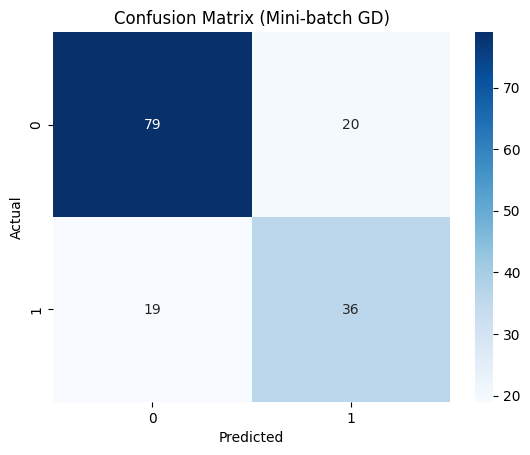

In [ ]:
cm = confusion_matrix(y_test, y_pred_mbgd)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Mini-batch GD)')
plt.show()


In [ ]:
# Lưu mô hình
joblib.dump(theta_mbgd, '/content/drive/MyDrive/datasets/mini_batch_model.pkl')
print("Mô hình mini-batch đã được lưu thành công!")


# Lưu scaler
scaler_path = '/content/drive/MyDrive/datasets/scaler1.pkl'
joblib.dump(scaler, scaler_path)
print("Scaler đã được lưu thành công!")


Mô hình mini-batch đã được lưu thành công!
Scaler đã được lưu thành công!


Hàm Stochastic gradient descent để huẩn luyện từng điểm một dữ liệu

In [ ]:
def stochastic_gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        for i in range(m):
            rand_idx = np.random.randint(0, m)
            X_i = X[rand_idx:rand_idx+1]
            y_i = y[rand_idx:rand_idx+1]
            h = sigmoid(np.dot(X_i, theta))
            gradient = (1/m) * np.dot(X_i.T, (h - y_i))
            theta -= learning_rate * gradient

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history




In [ ]:
theta = np.zeros(X_train.shape[1])
theta_sgd, cost_history_sgd = stochastic_gradient_descent(X_train, y_train, theta, learning_rate=0.01, iterations=1000)



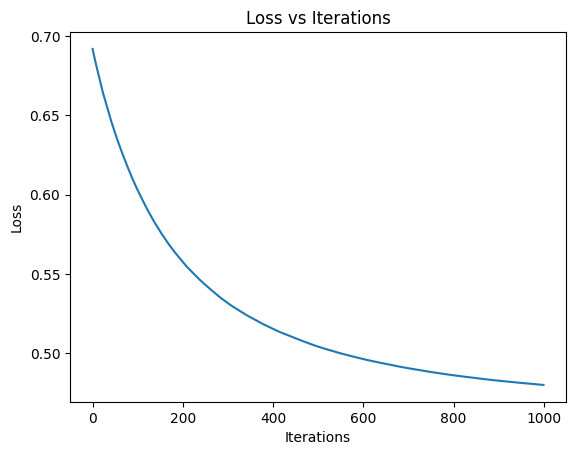

In [ ]:
plt.plot(cost_history_sgd)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss vs Iterations')
plt.show()


In [ ]:
y_pred_sgd = predict(X_test, theta_sgd)

acc = accuracy_score(y_test, y_pred_sgd)
print(f"Accuracy (SGD): {acc}")

cr = classification_report(y_test, y_pred_sgd)
print(f"Classification Report (SGD):\n {cr}")


Accuracy (SGD): 0.7337662337662337
Classification Report (SGD):
               precision    recall  f1-score   support

         0.0       0.80      0.79      0.79        99
         1.0       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



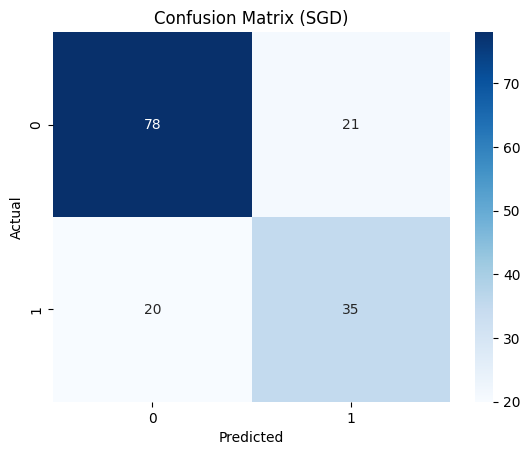

In [ ]:
cm = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (SGD)')
plt.show()


Sử dụng mô hình Logistic Regression từ thư viện sklearn

In [ ]:
file_path = '/content/drive/MyDrive/datasets/diabetes.csv'

data = np.genfromtxt(file_path, delimiter=',', skip_header=1)
X = data[:, :-1]
y = data[:, -1]

In [ ]:
# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Chia dữ liệu thành tập huấn luyện và kiểm tra (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)


In [ ]:
# Khởi tạo mô hình Logistic Regression từ thư viện sklearn
log_reg = LogisticRegression()

# Huấn luyện mô hình trên tập huấn luyện
log_reg.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_sklearn = log_reg.predict(X_test)


In [ ]:
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
confusion_matrix_sklearn = confusion_matrix(y_test, y_pred_sklearn)
classification_report_sklearn = classification_report(y_test, y_pred_sklearn)

print(f"Accuracy (Logistic Regression - sklearn): {accuracy_sklearn}")
print(f"Classification Report (Logistic Regression - sklearn):\n {classification_report_sklearn}")


Accuracy (Logistic Regression - sklearn): 0.7532467532467533
Classification Report (Logistic Regression - sklearn):
               precision    recall  f1-score   support

         0.0       0.81      0.80      0.81        99
         1.0       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



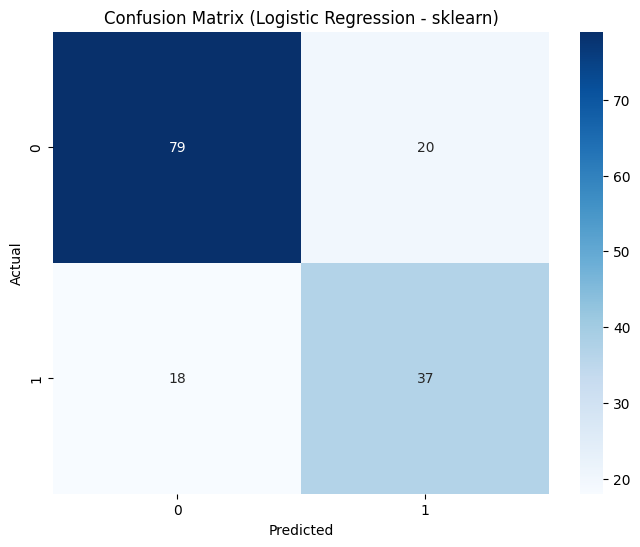

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_sklearn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression - sklearn)')
plt.show()


**Lưu mô hình**

### **Dự án: Xây dựng và so sánh các mô hình Hồi quy Logistic để dự đoán bệnh Tiểu đường**

**Mục tiêu:** Phát triển và so sánh hiệu suất của các thuật toán Hồi quy Logistic tự xây dựng (Batch, Mini-Batch, Stochastic Gradient Descent) với mô hình từ thư viện scikit-learn để dự đoán khả năng mắc bệnh tiểu đường.

**Kỹ thuật & Công cụ:**
*   **Tiền xử lý dữ liệu:** Chuẩn hóa dữ liệu bằng `StandardScaler`, chia tập huấn luyện/kiểm tra.
*   **Thuật toán Hồi quy Logistic:** Tự triển khai các hàm `sigmoid`, `compute_cost`, `predict` và ba phương pháp tối ưu hóa Gradient Descent:
    *   **Batch Gradient Descent (BGD):** Tối ưu hóa trên toàn bộ tập dữ liệu.
    *   **Mini-Batch Gradient Descent (MBGD):** Tối ưu hóa trên các tập dữ liệu con (batch size = 32), cải thiện hiệu quả tính toán và độ hội tụ.
    *   **Stochastic Gradient Descent (SGD):** Tối ưu hóa trên từng mẫu dữ liệu ngẫu nhiên, giúp thoát khỏi các cực tiểu cục bộ.
*   **Mô hình Baseline:** Sử dụng `LogisticRegression` từ thư viện `scikit-learn` để so sánh hiệu suất.
*   **Đánh giá mô hình:** Sử dụng các chỉ số `Accuracy Score`, `Classification Report` (Precision, Recall, F1-score) và `Confusion Matrix`:
    *   **Precision (Độ chính xác):** Tỷ lệ các trường hợp dự đoán là dương tính thực sự là dương tính. Nó trả lời câu hỏi: Trong số những người mà mô hình dự đoán mắc bệnh, có bao nhiêu người thực sự mắc bệnh?
    *   **Recall (Độ phủ/Độ nhạy):** Tỷ lệ các trường hợp dương tính thực sự được mô hình dự đoán đúng là dương tính. Nó trả lời câu hỏi: Trong số tất cả những người thực sự mắc bệnh, mô hình đã tìm thấy bao nhiêu người?
    *   **F1-score:** Là trung bình điều hòa của Precision và Recall, cung cấp một chỉ số cân bằng về hiệu suất của mô hình, đặc biệt hữu ích khi các lớp không cân bằng.
*   **Trực quan hóa:** Biểu đồ `Loss vs. Iterations` để theo dõi quá trình hội tụ của thuật toán, `Confusion Matrix` bằng `seaborn.heatmap` để đánh giá chi tiết hiệu suất phân loại.
*   **Lưu/Tải mô hình:** Sử dụng `joblib` để lưu và tải các trọng số mô hình (`theta`) và `StandardScaler`.
*   **Công cụ:** Python, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, Joblib.

**Kết quả nổi bật:**
*   **Độ chính xác (Accuracy):**
    *   Mini-Batch Gradient Descent (Tự xây dựng): ~0.747
    *   Batch Gradient Descent (Tự xây dựng): ~0.734
    *   Stochastic Gradient Descent (Tự xây dựng): ~0.734
    *   Logistic Regression (scikit-learn): ~0.753
*   Mô hình Mini-Batch Gradient Descent tự triển khai cho thấy hiệu suất cạnh tranh với các phương pháp Gradient Descent khác và đạt gần với mô hình từ thư viện `scikit-learn`.
*   Hiểu sâu sắc về cơ chế hoạt động của Hồi quy Logistic và các biến thể Gradient Descent thông qua việc triển khai từ đầu.

**Đóng góp:**
*   Phân tích và tiền xử lý dữ liệu y tế để chuẩn bị cho quá trình huấn luyện mô hình học máy.
*   Xây dựng các thuật toán học máy cơ bản mà không cần thư viện cấp cao, củng cố kiến thức về lý thuyết nền tảng.
*   So sánh và đánh giá khách quan hiệu suất của các mô hình, rút ra nhận định về ưu nhược điểm của từng phương pháp tối ưu hóa.
*   Lưu trữ và tái sử dụng mô hình, cho thấy khả năng triển khai thực tế.

In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

# Lưu mô hình Logistic Regression
model_path = '/content/drive/MyDrive/datasets/diabetes_logistic_regression_model.pkl'
joblib.dump(log_reg, model_path)

# Nếu bạn đã sử dụng StandardScaler, hãy lưu scaler
scaler_path = '/content/drive/MyDrive/datasets/scaler.pkl'
scaler = StandardScaler()
scaler.fit(X_train)  # Huấn luyện scaler với tập dữ liệu huấn luyện
joblib.dump(scaler, scaler_path)

['/content/drive/MyDrive/datasets/scaler.pkl']

### **Dự án: Xây dựng và so sánh các mô hình Hồi quy Logistic để dự đoán bệnh Tiểu đường**

**Mục tiêu:** Phát triển và so sánh hiệu suất của các thuật toán Hồi quy Logistic tự xây dựng (Batch, Mini-Batch, Stochastic Gradient Descent) với mô hình từ thư viện scikit-learn để dự đoán khả năng mắc bệnh tiểu đường.

**Kỹ thuật & Công cụ:**
*   **Tiền xử lý dữ liệu:** Chuẩn hóa dữ liệu bằng `StandardScaler`, chia tập huấn luyện/kiểm tra.
*   **Thuật toán Hồi quy Logistic:** Tự triển khai các hàm `sigmoid`, `compute_cost`, `predict` và ba phương pháp tối ưu hóa Gradient Descent:
    *   **Batch Gradient Descent (BGD):** Tối ưu hóa trên toàn bộ tập dữ liệu.
    *   **Mini-Batch Gradient Descent (MBGD):** Tối ưu hóa trên các tập dữ liệu con (batch size = 32), cải thiện hiệu quả tính toán và độ hội tụ.
    *   **Stochastic Gradient Descent (SGD):** Tối ưu hóa trên từng mẫu dữ liệu ngẫu nhiên, giúp thoát khỏi các cực tiểu cục bộ.
*   **Mô hình Baseline:** Sử dụng `LogisticRegression` từ thư viện `scikit-learn` để so sánh hiệu suất.
*   **Đánh giá mô hình:** Sử dụng các chỉ số `Accuracy Score`, `Classification Report` (Precision, Recall, F1-score) và `Confusion Matrix`.
*   **Trực quan hóa:** Biểu đồ `Loss vs. Iterations` để theo dõi quá trình hội tụ của thuật toán, `Confusion Matrix` bằng `seaborn.heatmap` để đánh giá chi tiết hiệu suất phân loại.
*   **Lưu/Tải mô hình:** Sử dụng `joblib` để lưu và tải các trọng số mô hình (`theta`) và `StandardScaler`.
*   **Công cụ:** Python, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, Joblib.

**Kết quả nổi bật:**
*   **Độ chính xác (Accuracy):**
    *   Mini-Batch Gradient Descent (Tự xây dựng): ~0.747
    *   Batch Gradient Descent (Tự xây dựng): ~0.734
    *   Stochastic Gradient Descent (Tự xây dựng): ~0.734
    *   Logistic Regression (scikit-learn): ~0.753
*   **Precision, Recall, F1-score (cho lớp bệnh tiểu đường - lớp 1.0):**
    *   **Mini-Batch Gradient Descent (Tự xây dựng):** Precision: 0.64, Recall: 0.65, F1-score: 0.65
    *   **Batch Gradient Descent (Tự xây dựng):** Precision: 0.62, Recall: 0.64, F1-score: 0.63
    *   **Stochastic Gradient Descent (Tự xây dựng):** Precision: 0.62, Recall: 0.64, F1-score: 0.63
    *   **Logistic Regression (scikit-learn):** Precision: 0.65, Recall: 0.67, F1-score: 0.66
*   Mô hình Mini-Batch Gradient Descent tự triển khai cho thấy hiệu suất cạnh tranh với các phương pháp Gradient Descent khác và đạt gần với mô hình từ thư viện `scikit-learn`.
*   Hiểu sâu sắc về cơ chế hoạt động của Hồi quy Logistic và các biến thể Gradient Descent thông qua việc triển khai từ đầu.

**Đóng góp:**
*   Phân tích và tiền xử lý dữ liệu y tế để chuẩn bị cho quá trình huấn luyện mô hình học máy.
*   Xây dựng các thuật toán học máy cơ bản mà không cần thư viện cấp cao, củng cố kiến thức về lý thuyết nền tảng.
*   So sánh và đánh giá khách quan hiệu suất của các mô hình, rút ra nhận định về ưu nhược điểm của từng phương pháp tối ưu hóa.
*   Lưu trữ và tái sử dụng mô hình, cho thấy khả năng triển khai thực tế.